In [1]:
from typing import Iterable, Optional
from numbers import Number
import json
import pandas as pd
import numpy as np
from sigmaepsilon.math.optimize import BinaryGeneticAlgorithm as BGA
from sigmaepsilon.solid.fourier import NavierBeam, LoadGroup, PointLoad, LineLoad
import matplotlib.pyplot as plt
import mlflow
from mlflow.pyfunc import PyFuncModel
from utils import (
    INTERNAL_FORCE_COMPONENTS,
    CANONICAL_SCORE_NAME,
    CROSS_SECTION_PARAMETERS,
    print_system_info,
)
from utils.torchutils import get_torch_device
import torch
from tqdm import tqdm

print_system_info()

Python version: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
Operating System: Darwin 23.4.0
Platform: macOS-14.4-arm64-arm-64bit
Processor: arm
Machine: arm64
CPU count: 11


In [2]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
mlflow_tracking_uri = "sqlite:///mlflow.db"

In [3]:
# Load configuration file into a dictionary
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

# Extract section data from config
section_data: dict = config["section"]

# Extract section type
section_type: str = section_data["type"]
print(f"Section type from config: {section_type}")
        
# Collect data about section parameters
section_variables: list[str] = []
section_params: list[str] = []
section_variable_ranges = []
section_variable_default_values = []
for p in section_data["params"]:
    section_params.append(p)
    if section_data["params"][p]["variable"]:
        section_variables.append(p)
        section_variable_default_values.append(section_data["params"][p]["default"])
        section_variable_ranges.append(section_data["params"][p]["range"])

default_section_params = {p:section_data["params"][p]["default"] for p in section_params}

# Define other parameters
beam_length = 10000.0  # mm
number_of_modes = 20
num_evaluation_points = 100

# Set up MLflow tracking URI
mlflow.set_tracking_uri(mlflow_tracking_uri)

Section type from config: rectangular_hollow_section


In [4]:
def get_predictor_columns(task: str) -> list[str]:
    """Return the predictor column names for a given task."""
    if task == "failure_prediction":
        return section_variables + INTERNAL_FORCE_COMPONENTS
    elif task == "utilization_estimation":
        return section_variables + INTERNAL_FORCE_COMPONENTS
    elif task == "section_estimation":
        return section_variables
    elif task == "geometry_validation":
        return section_variables
    else:
        raise NotImplementedError(f"Task '{task}' is not implemented.")
    
    
def get_sample_data(
    task: str, 
    n_sample: int=100, 
    flavour: str="torch", 
    device:Optional[torch.device] = None
) -> pd.DataFrame:
    """Retrieve sample input data for a given task and flavour."""

    predictor_columns = get_predictor_columns(task)
    df = pd.read_csv(data_file_path)
    df = df.dropna()
    X_df = df[predictor_columns].iloc[:n_sample]
    
    if flavour == "sklearn":
        return X_df
    elif flavour == "torch":
        device = get_torch_device()
        X_np = X_df.to_numpy(dtype=np.float32)
        X_tensor = torch.tensor(X_np, device=device)
        return X_tensor
    

def get_all_runs(task:str, section_type:str) -> pd.DataFrame:
    """
    Retrieve all MLflow runs for a given task and section type.
    """
    # get the experiment
    experiment_name = f"{task}__{section_type}"
    experiment = mlflow.get_experiment_by_name(experiment_name)

    # get all runs for the experiment
    df_runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
    )

    return df_runs


def get_all_logged_models(task:str, section_type:str) -> pd.DataFrame:
    """
    Retrieve all logged models from MLflow.
    """
    experiment_name = f"{task}__{section_type}"
    experiment = mlflow.get_experiment_by_name(experiment_name)
    return mlflow.search_logged_models(experiment_ids=[experiment.experiment_id])


class Predictor:
    """A predictor class that wraps around a model and handles different flavours."""
    
    def __init__(self, model: PyFuncModel, predictor_columns: list[str], flavour:str="sklearn"):
        self.model = model
        self.predictor_columns = predictor_columns
        self.flavour = flavour

    def predict(self, X: pd.DataFrame | torch.Tensor | list) -> Iterable:
        """Make predictions using the model."""

        if isinstance(X, (list, np.ndarray)):
            X = np.array(X)
            X = np.atleast_2d(X)
            X = pd.DataFrame(X, columns=self.predictor_columns)
                
        if self.flavour == "sklearn":
            return self.model.predict(X[self.predictor_columns])
        elif self.flavour == "torch":
            if not isinstance(X, torch.Tensor):
                device = get_torch_device()
                X_np = X[self.predictor_columns].to_numpy(dtype=np.float32)
                X = torch.tensor(X_np, device=device)
            return self.model(X).detach().cpu().numpy().squeeze()
        else:
            raise NotImplementedError(f"Flavour '{self.flavour}' is not implemented.")
        
    def __str__(self):
        return self.model.__str__()
    
    def __repr__(self):
        return self.model.__repr__()


def get_best_model(
    task:str, 
    section_type:str,
    *, 
    test:bool=False, 
    n_sample: int=5,
    flavour: Optional[str]=None
) -> PyFuncModel:
        
    df_runs = get_all_runs(task, section_type)
    df_models = get_all_logged_models(task, section_type)

    df_models = df_models.merge(
        df_runs[["run_id", "tags.library", "tags.section_type", "tags.task", f"metrics.{CANONICAL_SCORE_NAME}"]],
        left_on="source_run_id",
        right_on="run_id",
        how="inner"
    ).drop(columns=["source_run_id"], axis=1)
    df_models.rename(
        columns={
            f"metrics.{CANONICAL_SCORE_NAME}": CANONICAL_SCORE_NAME,
            "tags.library": "flavour",
            "tags.section_type": "section_type",
            "tags.task": "task"
        }, 
        inplace=True
    )
    
    df_models = df_models[df_models["flavour"].isin(["sklearn", "torch"])]
    if flavour:
        df_models = df_models[df_models["flavour"] == flavour]
        if df_models.empty:
            raise ValueError(f"No models found for flavour '{flavour}'.")
        
    df_models.sort_values(CANONICAL_SCORE_NAME, ascending=False, inplace=True)
    df_best_model = df_models.iloc[0]
    best_model_run_id = df_best_model["run_id"]
    best_model_name = df_best_model["name"]
    best_model_uri = f"runs:/{best_model_run_id}/{best_model_name}"
    best_model_flavour = df_best_model["flavour"]
    
    if best_model_flavour == "sklearn":
        best_model = mlflow.sklearn.load_model(best_model_uri)
    elif best_model_flavour == "torch":
        device = get_torch_device()
        best_model = mlflow.pytorch.load_model(best_model_uri, device=device)
        best_model.eval()
    else:
        raise NotImplementedError(f"Library '{best_model_flavour}' is not implemented.")

    predictor_columns = get_predictor_columns(task)
    predictor = Predictor(best_model, predictor_columns=predictor_columns, flavour=best_model_flavour)

    if test:
        sample_data = get_sample_data(task, n_sample=n_sample, flavour=best_model_flavour)
        predictor.predict(sample_data)
    
    return predictor

In [5]:
tasks = ["failure_prediction", "utilization_estimation", "section_estimation", "geometry_validation"]
tasks = {task: dict() for task in tasks}

for task in tasks:
    predictor_columns = get_predictor_columns(task)
    best_model = get_best_model(task, section_type, test=True, flavour="sklearn")
    tasks[task] = {
        "model": best_model, 
        "predictor_columns": predictor_columns
    }

2025/11/13 23:02:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/13 23:02:24 INFO mlflow.store.db.utils: Updating database tables
2025-11-13 23:02:24 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-13 23:02:24 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-13 23:02:24 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-13 23:02:24 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


In [6]:
# Set up beam loads
beam_loads = LoadGroup(
    concentrated=LoadGroup(
        LC1=PointLoad(beam_length / 2, [1.0, 0.0]),
        LC2=PointLoad(beam_length / 2, [0.0, 1.0]),
    ),
    distributed=LoadGroup(
        LC3=LineLoad([0, beam_length], [1.0, 0.0]),
        LC4=LineLoad([beam_length / 2, beam_length], [0.0, 1.0]),
    ),
)

# Set up points of evaluation along the beam length
evaluation_points = np.linspace(0, beam_length, num_evaluation_points)

In [7]:
section_variables, section_variable_default_values

(['d', 'b', 't', 'r_out'], [100, 100, 6, 15])

In [8]:
def objective(input: Iterable[Number], *, penalty:float=1e12) -> float:    
    model = tasks["geometry_validation"]["model"]
    is_valid_geometry = model.predict(input)[0] == 1
    if not is_valid_geometry:
        return 2*penalty

    model = tasks["section_estimation"]["model"]
    output = model.predict(input)
    df = pd.DataFrame(output, columns=CROSS_SECTION_PARAMETERS)
    bending_stiffness = df["ixx"].values[0]
    area = df["area"].values[0]

    bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
    analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
    df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
    df.columns = ["mxx", "vy"]
    for comp in ["n", "myy", "vx", "mzz"]:
        df[comp] = 0.0
    for k, v in zip(section_variables, input):
        df[k] = v
    df = df[section_variables + INTERNAL_FORCE_COMPONENTS]

    # model = tasks["utilization_estimation"]["model"]
    # utilization = model.predict(df)
    # max_utilization = utilization.max()
    # has_failure = max_utilization > 1.0

    model = tasks["failure_prediction"]["model"]
    failure_prediction = model.predict(df)
    has_failure = failure_prediction.max() > 0.5

    result = area
    if has_failure:
        return penalty

    return result


objective([100, 100, 6, 15]), objective([120, 120, 12, 15])

(1000000000000.0, 4970.687049981421)

In [ ]:
bga = BGA(objective, section_variable_ranges, length=8, nPop=100, minimize=True)

Initial fitness: 1701.0834


Epoch 499/499 | Fitness: 968.9834: 100%|██████████| 499/499 [14:19<00:00,  1.72s/it]

✅ Optimization finished. Fitness: 968.9834


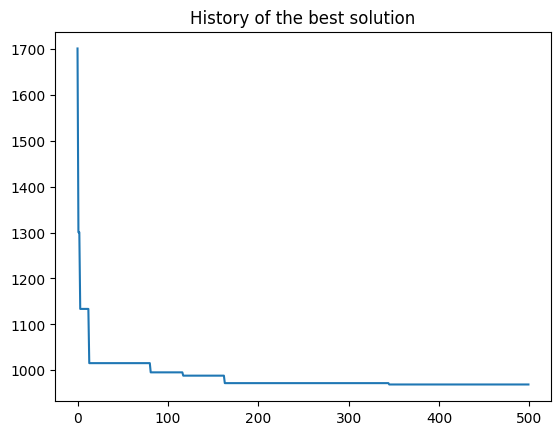

In [10]:
history = [objective(bga.best_phenotype())]

n_epochs = 500
bga.evolve(1)
n_epochs -= 1
fittness = bga.champion.fittness
tqdm.write(f"Initial fitness: {fittness:.4f}")
pbar = tqdm(total=n_epochs)
for epoch in range(n_epochs):
    bga.evolve(1)
    fittness = bga.champion.fittness
    history.append(fittness)
    pbar.set_description(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Fitness: {fittness:.4f}"
    )
    pbar.update(1)
pbar.close()

x = bga.champion.phenotype
fx = bga.champion.fittness
tqdm.write(f"✅ Optimization finished. Fitness: {fittness:.4f}")

solution = default_section_params.copy()
solution.update({k: v for k, v in zip(section_variables, x)})

plt.plot(history)
plt.title('History of the best solution')
plt.show()

## Validate results

Check wether the final configuration is admissible.

In [11]:
solution, section_variable_ranges

({'d': 99.31623931623932,
  'b': 161.33333333333334,
  't': 2.0043956043956044,
  'r_out': 17.11941391941392,
  'n_r': 4},
 [[20, 300], [20, 300], [2, 20], [8, 20]])

In [ ]:
from utils.section import construct_section, utilization, section_properties

section = construct_section(
    geometry_constructor=section_type,
    params=solution,
    material=config["material"],
    mesh_sizes=section_data["mesh_sizes"],
    calculate=True,
)

props = section_properties(section)
bending_stiffness = props["ixx"]
area = props["area"]

bernoulli_beam = NavierBeam(beam_length, number_of_modes, EI=bending_stiffness)
analysis_results = bernoulli_beam.linear_static_analysis(evaluation_points, beam_loads)
df = pd.concat([v.to_pandas()[["MZ", "SY"]] for v in analysis_results.values(deep=True)], ignore_index=True)
df.columns = ["mxx", "vy"]

utilization_max = -1.0
argmax = -1
for index, row in df.iterrows():
    loads = row.to_dict()
    stress = section.calculate_stress(**loads)
    material = section.materials[0]
    yield_strength = material.yield_strength
    utilizations = stress.get_stress()[0]["sig_vm"] / yield_strength
    utilization_max_ = utilizations.max()  # utilization(section, loads)
    if utilization_max_ > utilization_max:
        utilization_max = utilization_max_
        argmax = index

volume = beam_length * area
print(f"Optimized section area: {props['area']:.2f} mm²")
print(f"Optimized section volume: {volume:.2f} mm³")
print(f"Maximum utilization of the optimized section: {utilization_max:.4f}")


Optimized section area: 964.21 mm²
Optimized section volume: 9642087.54 mm³
Maximum utilization of the optimized section: 0.7503


In [17]:
for comp in ["n", "myy", "vx", "mzz"]:
    df[comp] = 0.0
for k, v in solution.items():
    df[k] = v
df = df[section_variables + INTERNAL_FORCE_COMPONENTS]

critical_loads = df[INTERNAL_FORCE_COMPONENTS].iloc[argmax].to_dict()
utilization_max = utilization(section, critical_loads)

model = tasks["utilization_estimation"]["model"]
critical_loads = df.iloc[argmax].values
estimated_utilization = model.predict(critical_loads)[0]
print(f"True maximum utilization of the optimized section: {utilization_max:.4f}")
print(f"Estimated maximum utilization of the optimized section: {estimated_utilization:.4f}")

model = tasks["failure_prediction"]["model"]
failure_prediction = model.predict(critical_loads)[0]
print(f"Failure prediction of the optimized section (0: no failure, 1: failure): {failure_prediction}")

True maximum utilization of the optimized section: 0.7503
Estimated maximum utilization of the optimized section: 1.5959
Failure prediction of the optimized section (0: no failure, 1: failure): 0


In [14]:
model = tasks["section_estimation"]["model"]
input = [solution[k] for k in section_variables]
output = model.predict(input)
df_out = pd.DataFrame(output, columns=CROSS_SECTION_PARAMETERS)
estimated_area = df_out["area"].values[0]
print(f"True area of the optimized section: {area:.2f} mm²")
print(f"Estimated area of the optimized section: {estimated_area:.2f} mm²")

True area of the optimized section: 964.21 mm²
Estimated area of the optimized section: 968.98 mm²


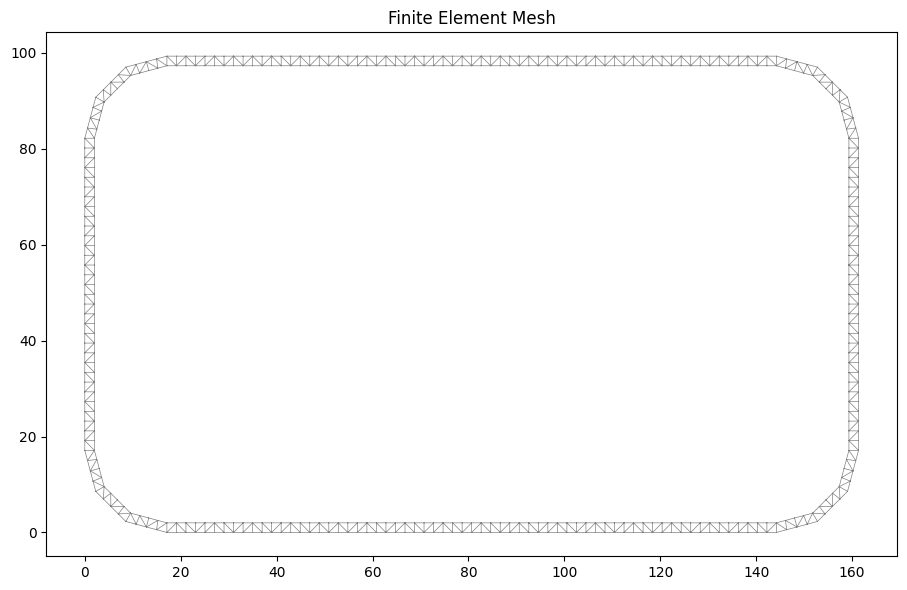

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
section.plot_mesh(ax=ax, materials=False)
plt.show()